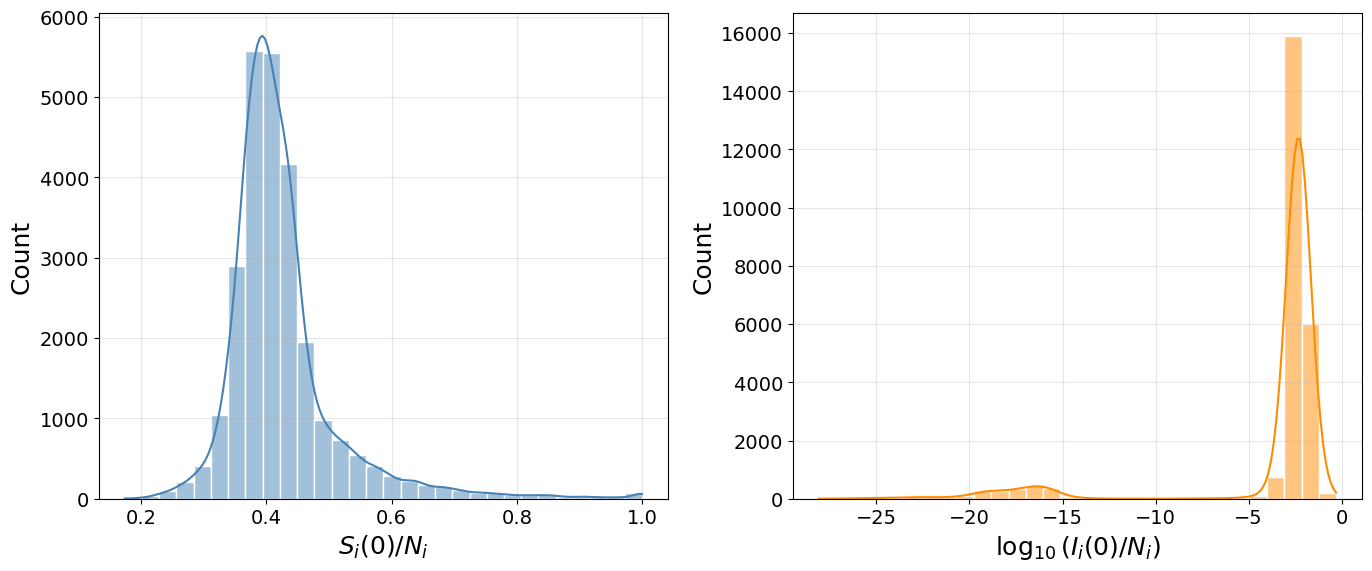

In [1]:
# ============================================================
# Figure 1 — Empirical distribution of fitted initial conditions
# Output: pix/ic_distribution.pdf
# ============================================================
# Empirical distribution of fitted initial conditions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
bads = ["AK", "HI", "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @bads and state2 not in @bads")

S_vals = pd.concat([res['S1_0'], res['S2_0']])
I_vals = pd.concat([res['I1_0'], res['I2_0']])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(S_vals, kde=True, ax=ax1, bins=30, color='steelblue', edgecolor='white')
ax1.set_xlabel(r'$S_i(0) / N_i$', fontsize=18)
ax1.set_ylabel('Count', fontsize=18)
ax1.grid(True, alpha=0.3)

sns.histplot(np.log10(I_vals[I_vals > 0]), kde=True, ax=ax2, bins=30, color='darkorange', edgecolor='white')
ax2.set_xlabel(r'$\log_{10}(I_i(0) / N_i)$', fontsize=18)
ax2.set_ylabel('Count', fontsize=18)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pix/ic_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/ic_distribution.pdf', bbox_inches='tight')
plt.show()


/var/folders/gd/3jlj0h2s037_tf9_vtdmy16m0000gn/T/ipykernel_35319/197821940.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


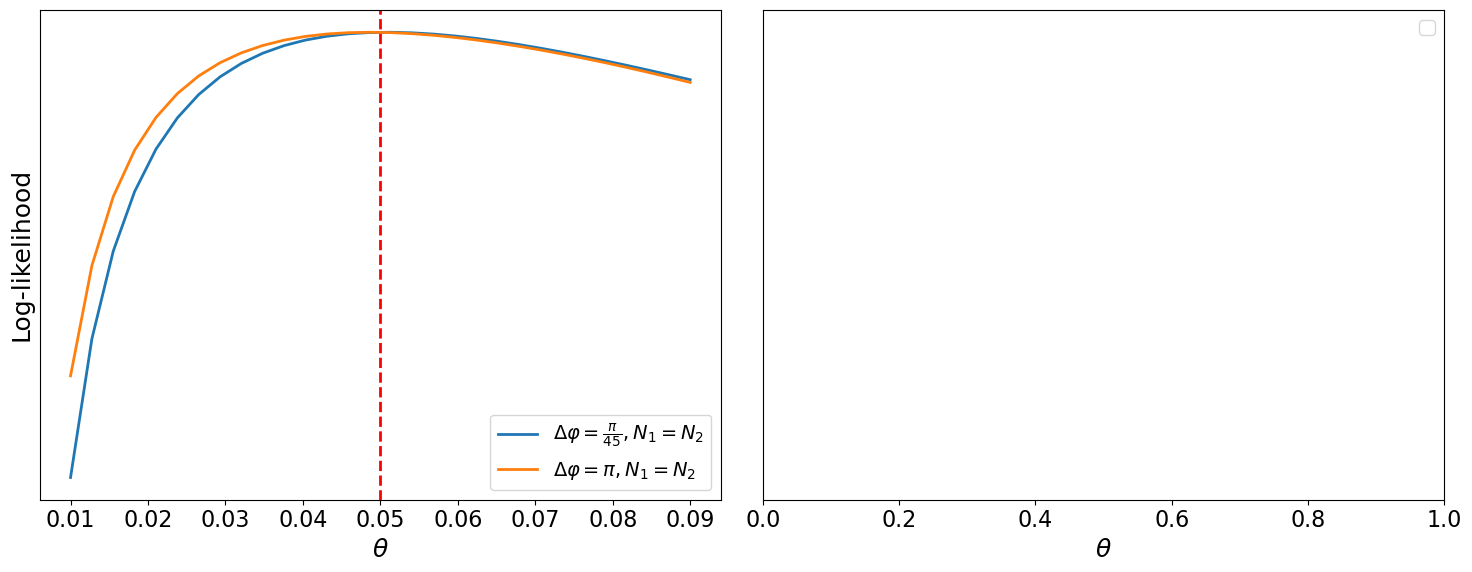

In [2]:
# ============================================================
# Figure 2 — Log-likelihood vs theta: simulated (left) + real-data state pairs (right)
# Output: pix/likelihood_surface.pdf
# ============================================================
# Three regimes on one panel + real data likelihood surfaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective
from src.data_loader import load_real
#import us

np.random.seed(0)
thetas_sim = np.linspace(0.01, 0.09, 30)

disease = flu.Mortality
regions = ["A", "B"]
equal_pops = dict(zip(regions, [5e7, 5e7]))
different_pops = dict(zip(regions, [5e6, 1e7]))
n_season = 1
seasons = [2011 + s for s in range(n_season)]
equal_pops = {(s, r): equal_pops[r] for s in seasons for r in regions}
different_pops = {(s, r): different_pops[r] for s in seasons for r in regions}

theta = 0.05

# Identical ICs
S_id = np.full((n_season, 2), S_vals.median())
I_id = np.full((n_season, 2), I_vals.median())

# Similar ICs from empirical distribution
ind = np.random.choice(range(len(S_vals)), replace=False, size=2*n_season)
#S_sim = np.random.choice(S_vals, replace=True, size=2*n_season).reshape(-1, 2)
#I_sim = np.random.choice(I_vals, replace=True, size=2*n_season).reshape(-1, 2)
S_sim = S_vals.values[ind].reshape(-1,2)
I_sim = I_vals.values[ind].reshape(-1,2)
cases = [
    #(r'$\Delta\varphi=0$', S_id, I_id, 0, equal_pops),
    #(r'$\Delta\varphi=0$', S_sim, I_sim, 0, equal_pops),
    (r'$\Delta\varphi=\frac{\pi}{45}, N_1 = N_2$', S_sim, I_sim, 0*np.pi/45, equal_pops),
    (r'$\Delta\varphi=\pi, N_1 = N_2$', S_sim, I_sim, np.pi, equal_pops),
    # (r'$\Delta\varphi=\frac{\pi}{45}, N_1 \neq N_2$', S_sim, I_sim, np.pi/45, different_pops),
    # (r'$\Delta\varphi=\pi, N_1 \neq N_2$', S_sim, I_sim, np.pi, different_pops),
]
# choose 45 because np.pi / pairs.sort_values("phase_diff").phase_diff.median() ~ 45
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: simulated
ax = axes[0]
for label, S_init, I_init, phase2, pops in cases:
    packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=pops)
    true = dict(S_init=S_init, I_init=I_init, theta=theta)
    phase = np.array([0.0, phase2])
    obs = packer.sim(true, phase, disease)
    mu = obs['mu']
    obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * np.sqrt(disease.rho * (1 - disease.rho) * mu)
    obj = Objective(obs=obs, phase=phase, disease=disease, populations=pops)
    lls = np.array([-obj(packer.pack(dict(true, theta=th))) for th in thetas_sim])
    ax.plot(thetas_sim, lls - lls.max(), label=label, linewidth=2)

ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
ax.set_xlabel(r'$\theta$', fontsize=18)
ax.set_ylabel('Log-likelihood', fontsize=18)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=16)
ax.legend(fontsize=14)






# Right panel: real data
def plot_likelihood_surface(s1, s2, ax):
    regions = [us.states.lookup(s1).name, us.states.lookup(s2).name]
    pair = f'{min(s1,s2)}x{max(s1,s2)}'
    res = pd.read_csv(f'outputs/states/{pair}.csv')
    seasons = res['season'].unique().tolist()

    obs, phase = load_real(disease=disease, regions=regions, seasons=seasons,
                           mortality_path='data/pni_mortality/excess_deaths.csv')
    pop_df = pd.read_csv('data/pni_mortality/populations.csv', parse_dates=['date'])
    pop_df['season'] = pop_df['date'].dt.year + 1
    populations = {(row['season'], row['state']): row['population']
                   for _, row in pop_df.iterrows() if row['state'] in regions}

    packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
    theta_hat = res['theta'].iloc[0]
    fitted = dict(S_init=res[['S1_0', 'S2_0']].values,
                  I_init=res[['I1_0', 'I2_0']].values, 
                  theta=theta_hat)

    thetas = np.linspace(0.02, 0.499, 50)
    obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)
    lls = np.array([-obj(obj.packer.pack(dict(fitted, theta=th))) for th in thetas])
    lls = (lls - lls.max()) / (lls.max() - lls.min())

    label = f'{s1} x {s2}'
    line, = ax.plot(thetas, lls, linewidth=2, label=label)
    # Plot MLE as colored dot on the curve
    ll_at_mle = np.interp(theta_hat, thetas, lls)
    print(label, theta_hat) 
    #ax.plot(theta_hat, ll_at_mle, 'o', color=line.get_color(), markersize=10, zorder=5)

ax = axes[1]
# plot_likelihood_surface('GA', 'OH', ax=ax)
#plot_likelihood_surface('NM', 'OK', ax=ax)
#plot_likelihood_surface('OK', 'MI', ax=ax)
#plot_likelihood_surface('CA', 'NY', ax=ax)
# plot_likelihood_surface('CA', 'PA', ax=ax)
ax.set_xlabel(r'$\theta$', fontsize=18)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=16)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig('pix/likelihood_surface.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/likelihood_surface.pdf', bbox_inches='tight')
plt.show()


In [3]:
# ============================================================
# [REMOVED] Old SI "IC-asymmetry restores identifiability" figure.
# The similar/different IC-regime comparison has been dropped from
# the paper; the simulated CRLB analysis now draws ICs exclusively
# from the empirical distribution of real-data fits. See git history
# for the original content.
# ============================================================


819 / 1081 significant (0.758)


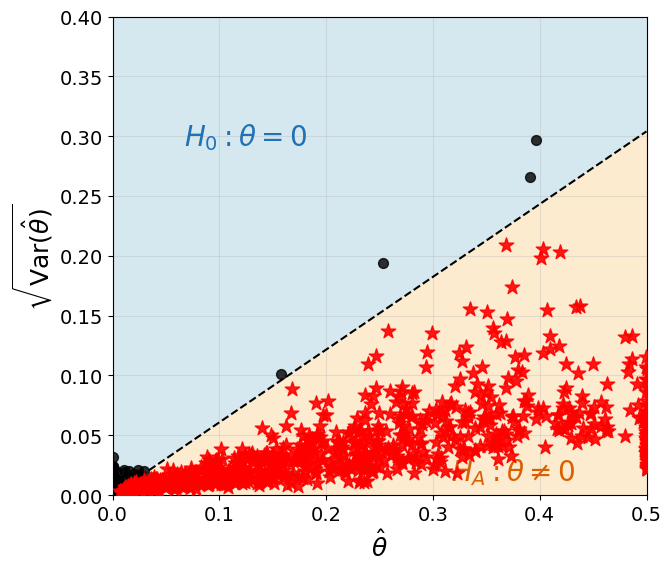

In [16]:
# ============================================================
# Figure 4 — theta-hat vs sqrt(Var(theta-hat)) scatter with significance
#            region, all US state pairs
# Output: pix/theta_vs_crlb.pdf
# ============================================================
# Theta estimate vs CRLB std with significance regions
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import std_from_precisions
threshold = norm.isf(0.05)

AKHI = ["AK", "HI", 'AZ']
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI")

# Aggregate across seasons per pair (Fisher informations add)
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    pairs.append({
        'state1': s1, 
        'state2': s2,
        'theta': grp['theta'].iloc[0],
        'sigma': std_from_precisions(grp['precision'].values)
    })
pairs = pd.DataFrame(pairs)
pairs['significant'] = pairs['theta'] > threshold * pairs['sigma']

fig, ax1 = plt.subplots(1, 1, figsize=(7, 6))#, gridspec_kw={'width_ratios': [1, 1]})

theta_max = 0.5
crlb_max = 0.4
t = np.linspace(0, theta_max, 100)
thr_line = t / threshold

# Shaded regions
ax1.fill_between(t, thr_line, crlb_max, color='#D5E8F0', zorder=0)
ax1.fill_between(t, 0, thr_line, color='#FDEBD0', zorder=0)
ax1.plot(t, thr_line, 'k--', linewidth=1.5, zorder=2)

# Non-significant points: black circles
nonsig = pairs[~pairs['significant']]
ax1.scatter(nonsig['theta'], nonsig['sigma'], alpha=0.8, s=50, color='black',
           marker='o', zorder=3)

# Significant points: red stars
sig = pairs[pairs['significant']]
ax1.scatter(sig['theta'], sig['sigma'], alpha=0.9, s=120, color='red',
           marker='*', zorder=4)

# Region labels
ax1.text(0.25 * theta_max, 0.75 * crlb_max, r'$H_0: \theta = 0$',
        fontsize=20, color='#2171B5', ha='center', va='center', fontstyle='italic')
ax1.text(0.75 * theta_max, 0.05 * crlb_max, r'$H_A:\theta \neq 0$',
        fontsize=20, color='#D95F02', ha='center', va='center', fontstyle='italic')

ax1.set_xlim(0, theta_max)
ax1.set_ylim(0, crlb_max)
ax1.set_xlabel(r'$\hat{\theta}$', fontsize=18)
ax1.set_ylabel(r'$\sqrt{\text{Var}(\hat\theta)}$', fontsize=18)
ax1.grid(True, alpha=0.3)

n_sig = sig.shape[0]
n_total = len(pairs)
print(f'{n_sig} / {n_total} significant ({n_sig/n_total:.3f})')



# sns.histplot(pairs['theta'], kde=False, ax=ax2, bins=15, color='steelblue', edgecolor='white')
# ax2.set_xlim(0, 0.5)
# ax2.set_xlabel(r'$\hat{\theta}$', fontsize=18)
# ax2.set_ylabel('Count', fontsize=18)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pix/theta_vs_crlb.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/theta_vs_crlb.pdf", bbox_inches='tight')
plt.show()

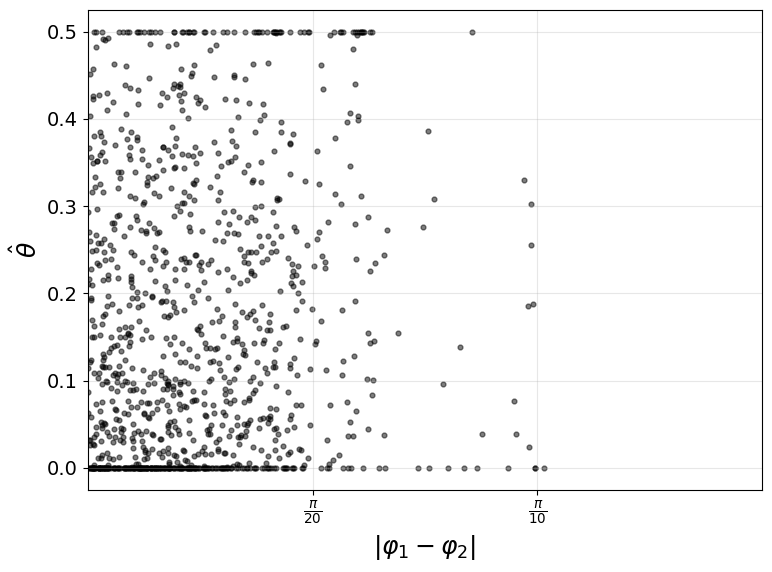

,state1,state2,theta,sigma,phase1,phase2,phase_diff
861,NE,SD,2.104199e-01,0.044851,0.167714,0.167616,0.000098
957,NY,WA,1.144823e-01,0.010423,0.035909,0.036041,0.000132
641,MD,VT,2.932152e-01,0.061603,0.053801,0.054016,0.000215
893,NJ,NY,6.252080e-02,0.009781,0.035675,0.035909,0.000235
56,AR,KS,2.004196e-18,0.013567,0.170453,0.170783,0.000329
...,...,...,...,...,...,...,...
983,OK,UT,5.000000e-01,0.035948,0.177210,6.261865,0.198530
678,MI,MT,1.002365e-01,0.017334,6.253561,0.169554,0.199178
62,AR,MI,1.454204e-01,0.011718,0.170453,6.253561,0.200078
491,KS,MI,2.352888e-01,0.035141,0.170783,6.253561,0.200407


In [5]:
# ============================================================
# Figure 5 — Phase difference |phi1 - phi2| vs theta-hat, state-pair scatter
# Output: pix/phase_diff_vs_theta.pdf
# ============================================================
# Phase difference vs theta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import std_from_precisions
from src.data_loader import estimate_phase

AKHI = ["AK", "HI" , "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI")

# Aggregate per pair
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    pairs.append({'state1': s1, 'state2': s2,
                  'theta': grp['theta'].iloc[0],
                  'sigma': std_from_precisions(grp['precision'].values)})
pairs = pd.DataFrame(pairs)

# Estimate phase for each state
import us
phase_cache = {}
for abbr in set(pairs['state1']) | set(pairs['state2']):
    state = us.states.lookup(abbr)
    if state:
        phase_cache[abbr] = estimate_phase(state.name)

pairs['phase1'] = pairs['state1'].map(phase_cache)
pairs['phase2'] = pairs['state2'].map(phase_cache)
pairs['phase_diff'] = np.abs(pairs['phase1'] - pairs['phase2'])
# Wrap to [0, pi]
pairs['phase_diff'] = np.minimum(pairs['phase_diff'], 2 * np.pi - pairs['phase_diff'])

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.scatter(pairs['phase_diff'], pairs['theta'], alpha=0.5, s=12, color='black')
ax1.set_xlabel(r'$|\varphi_1 - \varphi_2|$', fontsize=18)
ax1.set_ylabel(r'$\hat{\theta}$', fontsize=18)
ax1.set_xticks([np.pi/20, np.pi/10])
ax1.set_xticklabels([r'$\frac{\pi}{20}$', r'$\frac{\pi}{10}$'])
ax1.set_xlim(0, 3*np.pi/20)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pix/phase_diff_vs_theta.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/phase_diff_vs_theta.pdf", bbox_inches='tight')
plt.show()

pairs.sort_values("phase_diff").query("state1 != 'NM' and state2 != 'NM'")#.phase_diff.iloc[-1]

In [6]:
# ============================================================
# Figure 6 — Quantile regression of sqrt(CRLB) on population ratio (max/min)
# Output: none (prints QuantReg summary to stdout; figure code is commented out)
# ============================================================
# Population ratio and phase difference vs z-score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import std_from_precisions
from src.data_loader import estimate_phase
import us
import seaborn as sns
from scipy.stats import linregress

# from scipy.stats  import norm
# a = norm.isf(0.05)
AKHI = ["AK", "HI" , "AZ"]
CANY = ['CA','TX','FL','NY','PA','IL','OH','GA','NC','MI','NJ','VA','WA','AZ','MA','TN','IN','MD','MO','WI','CO','MN','SC','AL','LA']
#CANY = ['CA','TX','FL','NY','OH']
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI")

# Populations
pop_df = pd.read_csv('data/pni_mortality/populations.csv', parse_dates=['date'])
pop_df['season'] = pop_df['date'].dt.year + 1
avg_pop = pop_df.groupby('state')['population'].mean()

# Phases
phase_cache = {}
for abbr in res['state1'].unique().tolist() + res['state2'].unique().tolist():
    if abbr not in phase_cache:
        state = us.states.lookup(abbr)
        if state:
            phase_cache[abbr] = estimate_phase(state.name)

# Aggregate per pair
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    st1 = us.states.lookup(s1)
    st2 = us.states.lookup(s2)
    if st1 is None or st2 is None:
        continue
    p1 = avg_pop.get(st1.name, np.nan)
    p2 = avg_pop.get(st2.name, np.nan)
    if np.isnan(p1) or np.isnan(p2):
        continue
    pop_ratio = max(p1, p2) / min(p1, p2)
    ph1 = phase_cache.get(s1, np.nan)
    ph2 = phase_cache.get(s2, np.nan)
    phase_diff = abs(ph1 - ph2)
    phase_diff = min(phase_diff, 2 * np.pi - phase_diff)
    c = std_from_precisions(grp['precision'].values)
    th = grp['theta'].iloc[0]
    pairs.append({'s1': s1,
                  's2': s2,
                  'maxmin': pop_ratio,
                  'minmax': 1/ pop_ratio,
                  'phase_diff': phase_diff,
                  'sigma': c,
                  'z': th / c if c > 0 else np.nan})

pairs = pd.DataFrame(pairs).dropna()#.query("pop_ratio > 0.5")
#mins = pairs.groupby("pop_ratio").sigma.min()

#plt.scatter(pairs[v], pairs['sigma'])
#plt.xlabel("max pop /  min pop")
#plt.ylabel("sigma")
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
#plt.scatter(mins.index, mins.values)
# ax = sns.scatterplot(data=pairs, x=v, y='sigma')
# ax.set(xlabel=r"$\frac{\max(N_1,N_2)}{\min(N_1,N_2)}$", ylabel=r"$\sqrt{\mathrm{CRLB}}$", ylim=(0,0.2))
# plt.tight_layout()
# plt.savefig('pix/popratio_vs_crlb.png', dpi=150, bbox_inches='tight')
# plt.savefig('pix/popratio_vs_crlb.pdf', bbox_inches='tight')
# plt.show()

# slope, intercept, r, p, se = linregress(pairs[v], pairs['sigma'])
# print(f"Slope={slope:.4f}, p={p:.4f}, r²={r**2:.4f}")

import statsmodels.api as sm
mod = sm.QuantReg(pairs['sigma'], sm.add_constant(pairs['maxmin']))
res = mod.fit(q=0.05)                                                                           
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:                  sigma   Pseudo R-squared:              0.01456
Model:                       QuantReg   Bandwidth:                     0.01110
Method:                 Least Squares   Sparsity:                      0.04144
Date:                Sun, 05 Jul 2026   No. Observations:                 1081
Time:                        13:06:50   Df Residuals:                     1079
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0069      0.000     23.863      0.000       0.006       0.008
maxmin        -0.0003   1.87e-05    -15.914      0.000      -0.000      -0.000


In [7]:
# ============================================================
# Figure 7 — OLS regression of sqrt(CRLB) on 1/population-ratio (min/max)
# Output: none (prints OLS summary to stdout)
# Depends on `pairs` DataFrame produced in Figure 6
# ============================================================
import statsmodels.api as sm
X = sm.add_constant(pairs[['minmax']])
model = sm.OLS(pairs['sigma'], X).fit()
print(model.summary())                               

                            OLS Regression Results                            
Dep. Variable:                  sigma   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     26.06
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           3.91e-07
Time:                        13:06:50   Log-Likelihood:                 2162.0
No. Observations:                1081   AIC:                            -4320.
Df Residuals:                    1079   BIC:                            -4310.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0405      0.002     21.856      0.0

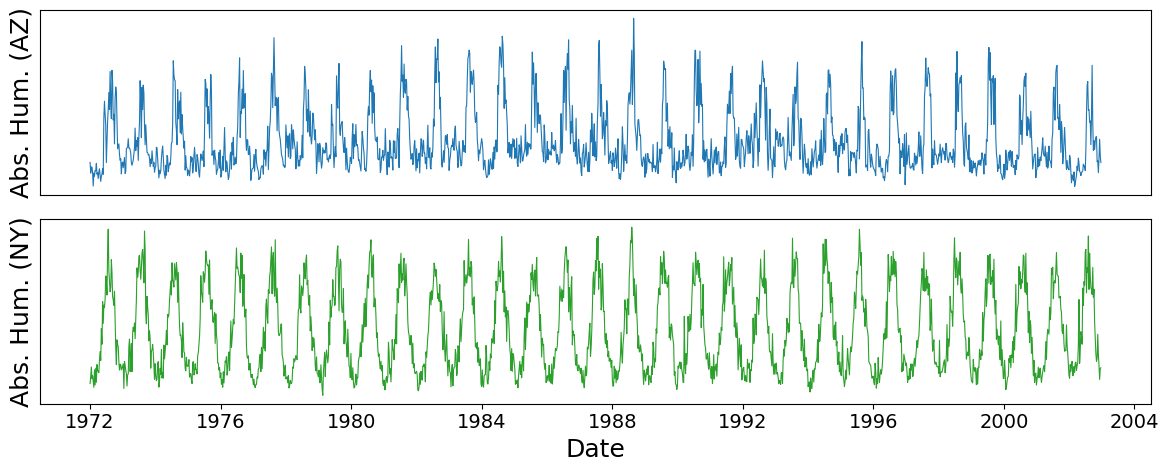

In [8]:
# ============================================================
# Figure 8 — Absolute humidity time series: Arizona vs New York
# Output: pix/abs_hum.pdf
# ============================================================
# Absolute humidity for Arizona, Oklahoma, and Texas
import pandas as pd
import matplotlib.pyplot as plt

ppairs = [('Arizona', 'C0'), ('New_York', 'C2')]
fig, axes = plt.subplots(len(ppairs), 1, figsize=(12, 5))

axes[0].set_xticks([])
axes[0].set_ylabel('Abs. Hum. (AZ)', fontsize=18)
axes[1].set_ylabel('Abs. Hum. (NY)', fontsize=18)
for (state, color), ax in zip(ppairs, axes):
    df = pd.read_csv(f'data/viboud/{state}.csv', parse_dates=['time'])
    ax.plot(df['time'], df['AH'], linewidth=0.8, color=color, label=state)
    
    ax.set_yticks([])

ax.set_xlabel('Date', fontsize=18)

plt.tight_layout()
plt.savefig('pix/abs_hum.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/abs_hum.pdf', bbox_inches='tight')
plt.show()


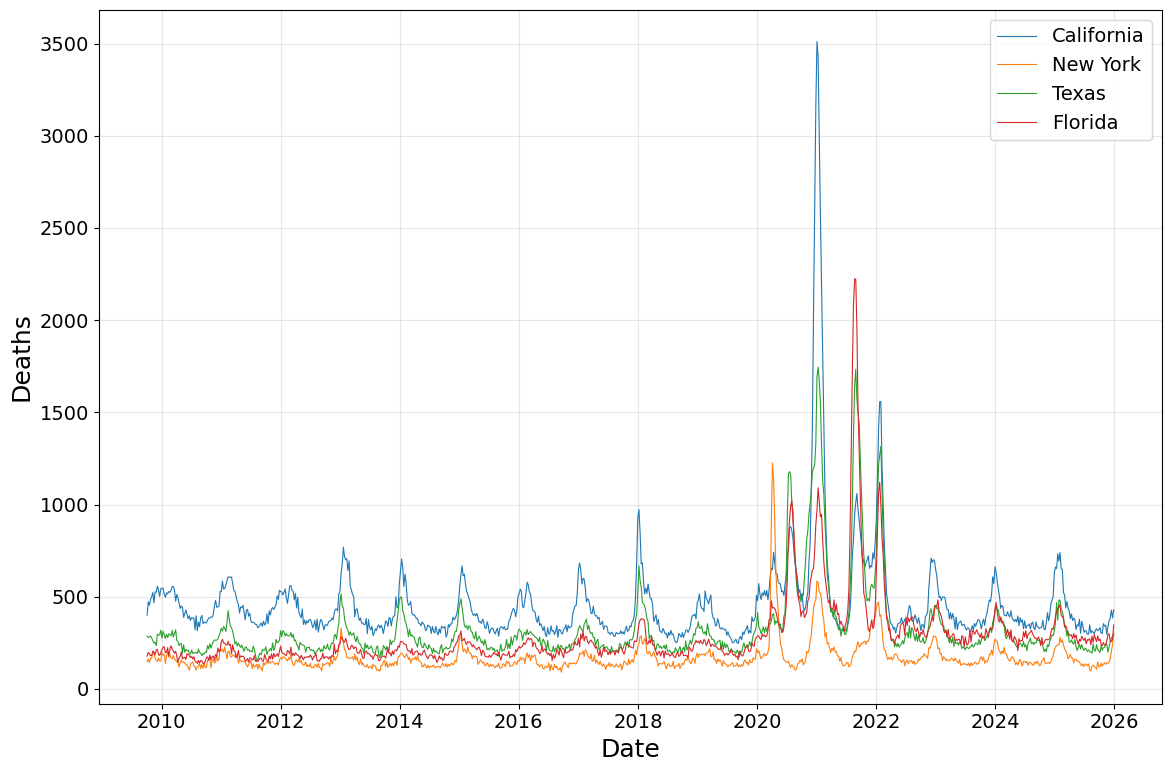

In [9]:
# ============================================================
# Figure 9 — Raw weekly P&I death counts, four representative states
# Output: pix/raw_deaths.pdf
# ============================================================
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
ax.set_ylabel("Deaths", fontsize=18)
ax.set_xlabel("Date", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.show()

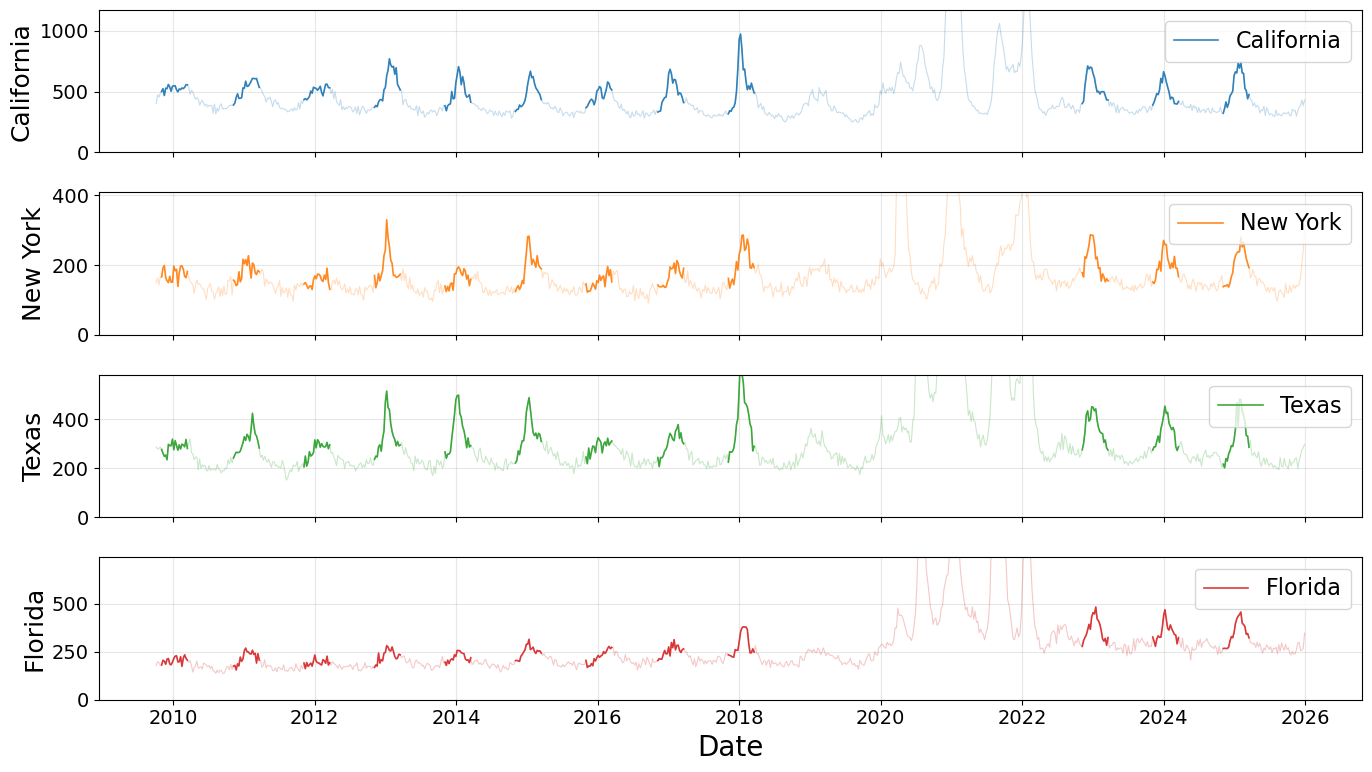

In [10]:
# ============================================================
# Figure 10 — Weekly P&I deaths with flu seasons highlighted (4 states)
# Output: pix/seasons_highlighted.pdf
# ============================================================
# P&I Deaths with flu seasons highlighted
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.flu import Mortality as flu

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
colors = {"California": "C0", "New York": "C1", "Texas": "C2", "Florida": "C3"}
seasons = list(range(2010, 2019)) + [2023, 2024, 2025]
n_weeks = flu.n_weeks

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for ax, state in zip(axes, states):
    dd = df[df["state"] == state].sort_values("date")
    c = colors[state]

    # Full time series: light, transparent
    ax.plot(dd["date"], dd["deaths"], color=c, linewidth=0.8, alpha=0.25)

    # Flu seasons: dark, opaque
    for s_idx, season in enumerate(seasons):
        start = pd.Timestamp(year=season - 1, month=11, day=1)
        end = start + pd.Timedelta(weeks=n_weeks)
        mask = (dd["date"] >= start) & (dd["date"] < end)
        ss = dd[mask]
        if not ss.empty:
            ax.plot(ss["date"], ss["deaths"], color=c, linewidth=1.2, alpha=0.9,
                    label=state if s_idx == 0 else None)

    ax.set_ylim(0, dd["deaths"].max() / 3)
    ax.set_ylabel(state, fontsize=18)
    ax.legend(loc='upper right', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=20)
plt.tight_layout()
plt.savefig("pix/seasons_highlighted.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/seasons_highlighted.pdf", bbox_inches='tight')
plt.show()

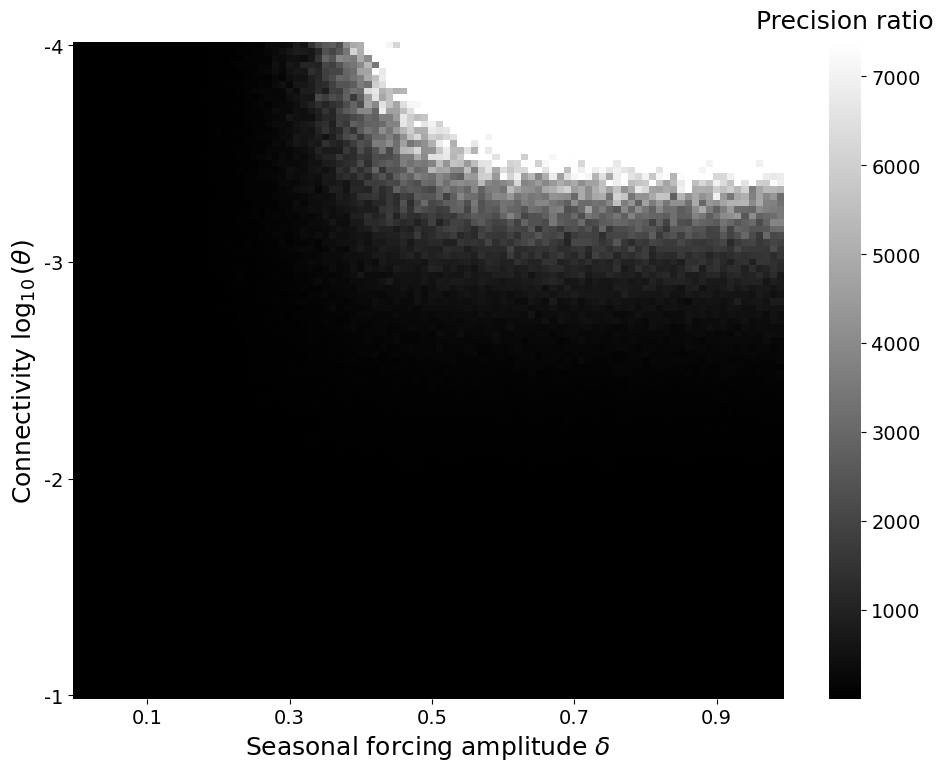

In [11]:
# ============================================================
# Figure 11 — Precision ratio heatmap (reverse-phase / in-phase) over
#             (theta, delta), with ICs drawn from the empirical distribution.
#             Values > 1 mean reverse-phase is more informative than in-phase.
# Output: pix/crlb_ratio.pdf
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed


def median_ratio(pp):
    # Precision(reverse-phase) / precision(in-phase); ratio > 1 when
    # reverse-phase pairs carry more Fisher info than in-phase pairs.
    sync = pp.query("phase2 == 0").precision.values
    unsync = pp.query("phase2 > 0").precision.values
    if len(sync) == 0 or len(unsync) == 0:
        return np.nan
    med_sync = np.median(sync)
    if med_sync <= 0:
        return np.nan
    return np.median(unsync) / med_sync


df = pd.read_csv("outputs/precision.csv")
df = df.rename(columns={'delta': 'amplitude'})

groups = list(df.groupby(['amplitude', 'theta']))
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for _, group in groups)
index = pd.MultiIndex.from_tuples([name for name, _ in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)
heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
amplitudes = heat.columns.values
thetas = heat.index.values
vals = heat.values[np.isfinite(heat.values)]
vmax = np.percentile(vals, 90)

hm = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False,
                 vmin=1, vmax=vmax, ax=ax, cbar=True, cbar_kws={})

cbar = hm.collections[0].colorbar
cbar.ax.set_title('Precision ratio', fontsize=18, pad=10)

x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)
ax.set_xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=18)
ax.set_ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=18)

plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/crlb_ratio.pdf", bbox_inches='tight')
plt.show()

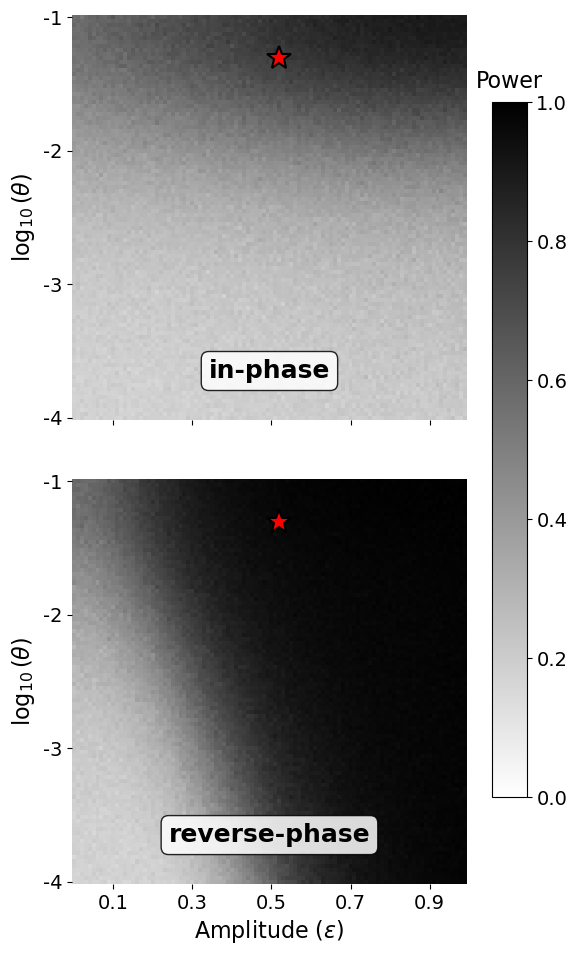

In [12]:
# ============================================================
# Figure 12 — Power heatmap (in-phase vs reverse-phase) with ICs
#             from the empirical distribution. Power is computed
#             under the 12-season aggregation used for the real-data
#             analysis (Fisher informations add). A red star marks
#             the flu operating point (theta = 0.05, delta = 0.517).
# Output: pix/power.pdf
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

# Flu operating point (from paper parameter table)
THETA_FLU = 0.05    # 5% connectivity
DELTA_FLU = 0.517   # seasonal forcing amplitude for flu

df = pd.read_csv("outputs/precision.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['log_theta'] = np.log10(df.theta)

z_alpha = norm.isf(0.05) #1.645

# 12-season aggregation: I_theta_total = 12 * I_theta_per_season, so aggregate
# std = 1/sqrt(12 * precision). SNR = theta / std = theta * sqrt(12 * precision).
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] * np.sqrt(12 * df['precision']))


def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

    # Red star at the flu operating point (theta, delta).
    x_flu = np.argmin(np.abs(amplitudes - DELTA_FLU)) + 0.5
    y_flu = np.argmin(np.abs(thetas - THETA_FLU)) + 0.5
    ax.plot(x_flu, y_flu, marker='*', color='red', markersize=18,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10,
            linestyle='None')


df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

# Stacked panels: in-phase on top, reverse-phase below
g = sns.FacetGrid(df_agg, row='phase2',
                  row_order=['in-phase', 'reverse-phase'],
                  height=5, aspect=1.2)
g.map_dataframe(draw_heatmap)
g.set_axis_labels(r'Amplitude ($\epsilon$)', r'$\log_{10}(\theta)$')
g.set_titles(row_template='')  # suppress default top titles

# Panel label INSIDE each panel (top-center), with a semi-opaque white box
# so the text stays readable against the heatmap.
for ax, label in zip(g.axes.flat, ['in-phase', 'reverse-phase']):
    ax.text(0.5, 0.15, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=18, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', alpha=0.85))

sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
sm.set_array([])
# Colorbar: no side label; place "Power" as a title above the bar.
cbar = g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8)
cbar.ax.set_title('Power', fontsize=16, pad=10)

plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
plt.show()

In [10]:
norm.isf(0.05)#1.645


1.6448536269514729